# Dataset Preparation

In [2282]:
import pandas as pd

file_path = "Domestic Interest Rates.csv"

# Skip the first few rows
df_raw = pd.read_csv(file_path, header=3)

df_raw.head()

,SORA Value Date,Unnamed: 1,Unnamed: 2,SORA Publication Date,SORA,SORA Index,Compound SORA - 1 month,Compound SORA - 3 month,Compound SORA - 6 month,Aggregate Volume of SORA Transactions (S$ MILLIONS),Highest Transacted Rate,Lowest Transacted Rate,SORA Calculation Method
0,2013,Jan,2.0,03 Jan 2013,0.0189,0.9632609297,0.0510,0.0576,0.0685,-,-,-,-
1,NaN,NaN,3.0,04 Jan 2013,0.0194,0.9632614416,0.0485,0.0576,0.0685,-,-,-,-
2,NaN,NaN,4.0,07 Jan 2013,0.0228,0.9632632468,0.0442,0.0577,0.0683,-,-,-,-
3,NaN,NaN,7.0,08 Jan 2013,0.0285,0.9632639989,0.0444,0.0579,0.0682,-,-,-,-
4,NaN,NaN,8.0,09 Jan 2013,0.0327,0.9632648619,0.0446,0.0579,0.0681,-,-,-,-


## Rename columns & fill rows

In [2283]:
df_raw.columns = [
    "Year", "Month", "Day",
    "Publication Date",
    "SORA",
    "SORA Index",
    "SORA_1M",
    "SORA_3M",
    "SORA_6M",
    "Volume",
    "High",
    "Low",
    "Method"
]

df_raw["Year"] = df_raw["Year"].ffill()
df_raw["Month"] = df_raw["Month"].ffill()
df_raw["Day"] = pd.to_numeric(df_raw["Day"], errors="coerce")
df_raw = df_raw[df_raw["Day"].notna()]
df_raw["Day"] = df_raw["Day"].astype(int)
df_raw["Year"] = df_raw["Year"].astype(int)
df_raw = df_raw.reset_index(drop=True)
df_raw.head(5)

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,High,Low,Method
0,2013,Jan,2,03 Jan 2013,0.0189,0.9632609297,0.0510,0.0576,0.0685,-,-,-,-
1,2013,Jan,3,04 Jan 2013,0.0194,0.9632614416,0.0485,0.0576,0.0685,-,-,-,-
2,2013,Jan,4,07 Jan 2013,0.0228,0.9632632468,0.0442,0.0577,0.0683,-,-,-,-
3,2013,Jan,7,08 Jan 2013,0.0285,0.9632639989,0.0444,0.0579,0.0682,-,-,-,-
4,2013,Jan,8,09 Jan 2013,0.0327,0.9632648619,0.0446,0.0579,0.0681,-,-,-,-


## Create a proper datetime column

In [2284]:
date_str = (
    df_raw["Year"].astype(str) + "-" +
    df_raw["Month"] + "-" +
    df_raw["Day"].astype(str)
)

df_raw["Date"] = pd.to_datetime(date_str, errors="coerce")

cols = ["SORA", "SORA Index", "SORA_1M", "SORA_3M", "SORA_6M", "Volume", "High", "Low"]

for col in cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw.tail()

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,High,Low,Method,Date
3318,2026,Mar,25,26 Mar 2026,1.1783,1.117958,1.0054,1.0743,1.1364,2372.0,1.30,0.5,Normal,2026-03-25
3319,2026,Mar,26,27 Mar 2026,1.1312,1.117992,1.0101,1.0733,1.1350,3112.0,1.30,0.6,Normal,2026-03-26
3320,2026,Mar,27,30 Mar 2026,1.2085,1.118103,1.0286,1.0715,1.1322,2933.0,1.35,0.5,Normal,2026-03-27
3321,2026,Mar,30,31 Mar 2026,1.1552,1.118139,1.0327,1.0697,1.1324,1293.0,1.35,0.6,Normal,2026-03-30
3322,2026,Mar,31,01 Apr 2026,0.9954,1.118169,1.0308,1.0708,1.1313,1219.0,1.30,0.6,Normal,2026-03-31


In [2285]:
print(df_raw.head(20))
print(df_raw.columns)

    Year Month  Day Publication Date    SORA  SORA Index  SORA_1M  SORA_3M  \
0   2013   Jan    2      03 Jan 2013  0.0189    0.963261   0.0510   0.0576   
1   2013   Jan    3      04 Jan 2013  0.0194    0.963261   0.0485   0.0576   
2   2013   Jan    4      07 Jan 2013  0.0228    0.963263   0.0442   0.0577   
3   2013   Jan    7      08 Jan 2013  0.0285    0.963264   0.0444   0.0579   
4   2013   Jan    8      09 Jan 2013  0.0327    0.963265   0.0446   0.0579   
5   2013   Jan    9      10 Jan 2013  0.0202    0.963265   0.0445   0.0578   
6   2013   Jan   10      11 Jan 2013  0.0247    0.963266   0.0444   0.0577   
7   2013   Jan   11      14 Jan 2013  0.0224    0.963268   0.0441   0.0575   
8   2013   Jan   14      15 Jan 2013  0.0235    0.963268   0.0434   0.0575   
9   2013   Jan   15      16 Jan 2013  0.0274    0.963269   0.0429   0.0575   
10  2013   Jan   16      17 Jan 2013  0.0266    0.963270   0.0423   0.0572   
11  2013   Jan   17      18 Jan 2013  0.0255    0.963271   0.039

### Add Fx & Fed datasets

In [2286]:
fx = pd.read_csv("Exchange Rates.csv", skiprows=6)
fed = pd.read_csv("chart_20260318T123749.csv")

In [2287]:
print(fx.head())
print(fx.columns)

print(fed.head())
print(fed.columns)

  End of Period Unnamed: 1  Unnamed: 2 S$ Per Unit of Euro  \
0          2013        Jan         2.0              1.6221   
1           NaN        NaN         3.0              1.6060   
2           NaN        NaN         4.0              1.6020   
3           NaN        NaN         7.0              1.6063   
4           NaN        NaN         8.0              1.6126   

  S$ Per Unit of Pound Sterling S$ Per Unit of US Dollar  \
0                        1.9960                   1.2208   
1                        1.9825                   1.2227   
2                        1.9757                   1.2296   
3                        1.9752                   1.2307   
4                        1.9795                   1.2289   

  S$ Per 100 Units of Australian Dollar S$ Per 100 Units of Canadian Dollar  \
0                                127.92                              123.74   
1                                128.09                              123.93   
2                            

In [2288]:
fx.columns = [
    "Year", "Month", "Day",
    "EUR",
    "GBP",
    "USD",
    "AUD",
    "CAD",
    "CNY",
    "HKD",
    "INR",
    "IDR",
    "JPY",
    "KRW",
    "MYR",
    "NTD",
    "NZD",
    "PHP",
    "QAR",
    "SAR",
    "CHF",
    "THB",
    "AED",
    "VND"
]


fx["Year"] = fx["Year"].ffill()
fx["Month"] = fx["Month"].ffill()

fx.head()

,Year,Month,Day,EUR,GBP,USD,AUD,CAD,CNY,HKD,...,MYR,NTD,NZD,PHP,QAR,SAR,CHF,THB,AED,VND
0,2013,Jan,2.0,1.6221,1.9960,1.2208,127.92,123.74,19.59,15.75,...,40.19,4.2091,102.23,2.9863,33.53,32.55,134.30,4.0072,33.24,0.005858
1,2013,Jan,3.0,1.6060,1.9825,1.2227,128.09,123.93,19.63,15.77,...,40.27,4.2161,101.72,2.9964,33.58,32.60,132.82,4.0247,33.29,0.005866
2,2013,Jan,4.0,1.6020,1.9757,1.2296,128.30,124.32,19.73,15.86,...,40.38,4.2400,101.27,3.0082,33.77,32.79,132.51,4.0381,33.48,0.005897
3,2013,Jan,7.0,1.6063,1.9752,1.2307,128.90,124.65,19.76,15.88,...,40.45,4.2436,102.14,3.0102,33.80,32.82,132.90,4.0417,33.51,0.005903
4,2013,Jan,8.0,1.6126,1.9795,1.2289,128.78,124.52,19.74,15.85,...,40.42,4.2360,102.69,3.0072,33.76,32.77,133.37,4.0384,33.46,0.005894


In [2289]:
fx["Day"] = pd.to_numeric(fx["Day"], errors="coerce")
fx = fx[fx["Day"].notna()]
fx["Day"] = fx["Day"].astype(int)
fx["Year"] = fx["Year"].astype(int)

In [2290]:
fx["Date"] = pd.to_datetime(
    fx["Year"].astype(str) + "-" +
    fx["Month"].astype(str) + "-" +
    fx["Day"].astype(str),
    errors="coerce"
)

fx.head()

,Year,Month,Day,EUR,GBP,USD,AUD,CAD,CNY,HKD,...,NTD,NZD,PHP,QAR,SAR,CHF,THB,AED,VND,Date
0,2013,Jan,2,1.6221,1.9960,1.2208,127.92,123.74,19.59,15.75,...,4.2091,102.23,2.9863,33.53,32.55,134.30,4.0072,33.24,0.005858,2013-01-02
1,2013,Jan,3,1.6060,1.9825,1.2227,128.09,123.93,19.63,15.77,...,4.2161,101.72,2.9964,33.58,32.60,132.82,4.0247,33.29,0.005866,2013-01-03
2,2013,Jan,4,1.6020,1.9757,1.2296,128.30,124.32,19.73,15.86,...,4.2400,101.27,3.0082,33.77,32.79,132.51,4.0381,33.48,0.005897,2013-01-04
3,2013,Jan,7,1.6063,1.9752,1.2307,128.90,124.65,19.76,15.88,...,4.2436,102.14,3.0102,33.80,32.82,132.90,4.0417,33.51,0.005903,2013-01-07
4,2013,Jan,8,1.6126,1.9795,1.2289,128.78,124.52,19.74,15.85,...,4.2360,102.69,3.0072,33.76,32.77,133.37,4.0384,33.46,0.005894,2013-01-08


In [2291]:
for col in [
    "EUR",
    "GBP",
    "USD",
    "AUD",
    "CAD",
    "CNY",
    "HKD",
    "INR",
    "IDR",
    "JPY",
    "KRW",
    "MYR",
    "NTD",
    "NZD",
    "PHP",
    "QAR",
    "SAR",
    "CHF",
    "THB",
    "AED",
    "VND"
]:
    fx[col] = pd.to_numeric(fx[col], errors="coerce")

In [2292]:
fx = fx.drop(columns=["Year", "Month", "Day"])
fx = fx.sort_values("Date").reset_index(drop=True)

In [2293]:
fx = fx.set_index("Date")
fx_pct = fx.pct_change()
fx_pct = fx_pct.dropna()
corr_matrix = fx_pct.corr()


<Figure size 1200x1000 with 0 Axes>

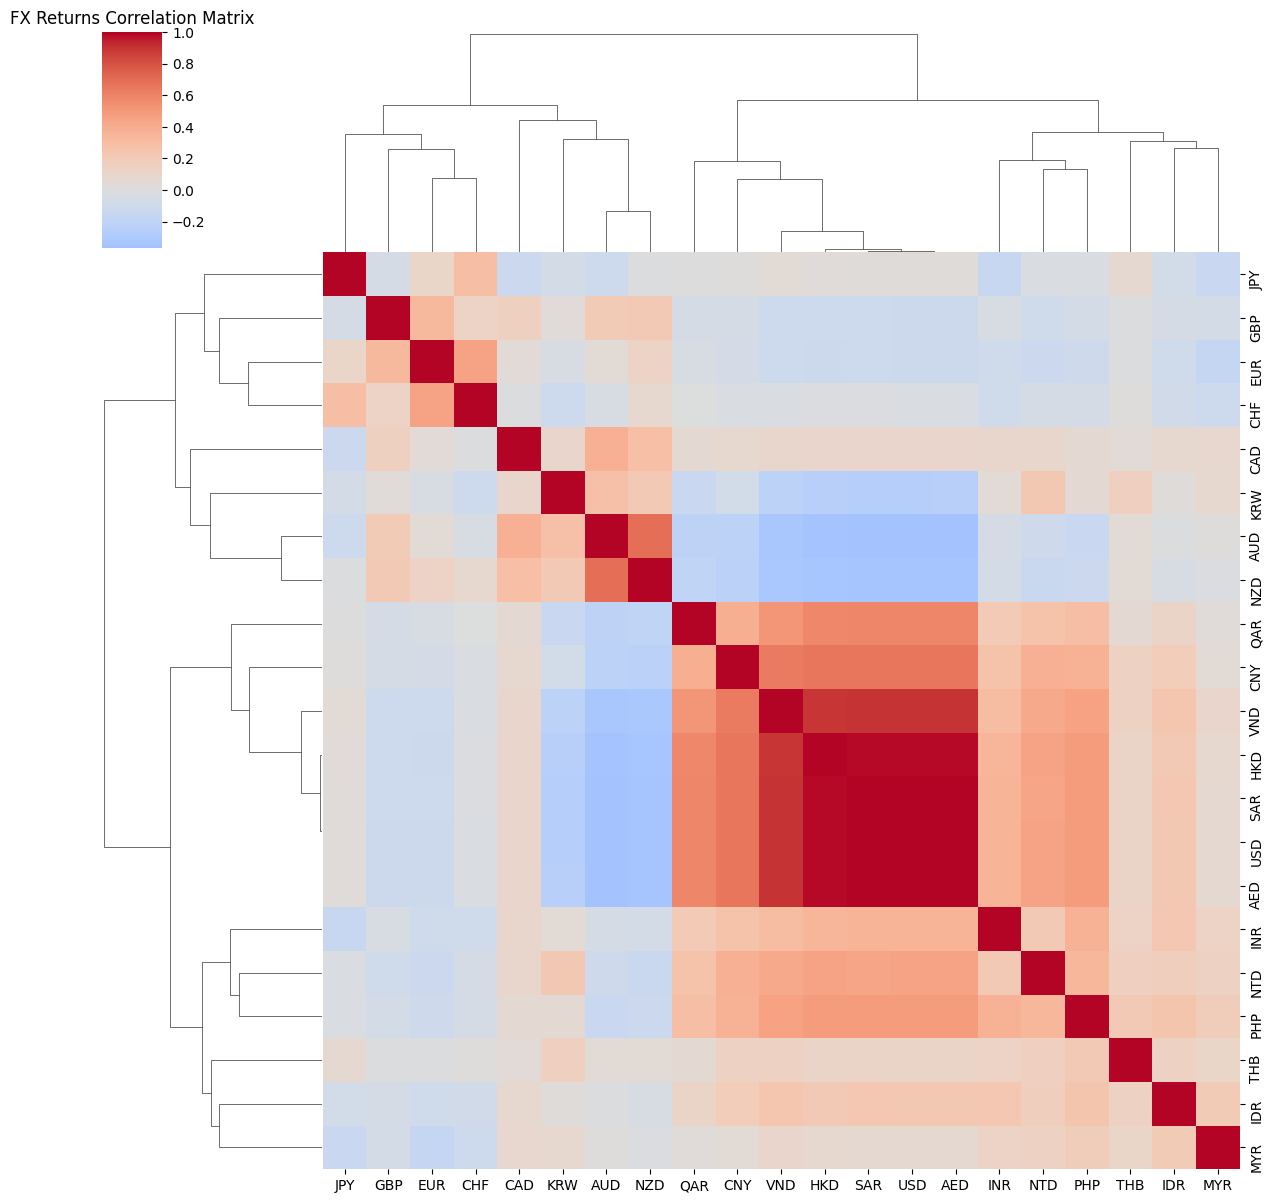

In [2294]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.clustermap(
    fx_pct.corr(),
    cmap="coolwarm",
    center=0,
    figsize=(12, 12)
)
plt.title("FX Returns Correlation Matrix")
plt.show()

In [2295]:
fed = fed.rename(columns={
    "Date": "Date",
    "Value": "FedRate"
})

fed["Date"] = pd.to_datetime(fed["Date"], format="%m/%d/%Y")
fed["FedRate"] = pd.to_numeric(fed["FedRate"], errors="coerce")

fed = fed.sort_values("Date")

In [2296]:
df = df_raw.copy()

# Merge FX
df = df.merge(fx, on="Date", how="left")

# Merge Fed
df = df.merge(fed, on="Date", how="left")

# Fill missing macro values
df = df.sort_values("Date").ffill()

df.tail()

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,NTD,NZD,PHP,QAR,SAR,CHF,THB,AED,VND,FedRate
3318,2026,Mar,25,26 Mar 2026,1.1783,1.117958,1.0054,1.0743,1.1364,2372.0,...,4.0043,74.46,2.1324,35.00,34.07,162.01,3.9037,34.82,0.004853,3.64
3319,2026,Mar,26,27 Mar 2026,1.1312,1.117992,1.0101,1.0733,1.1350,3112.0,...,4.0146,74.44,2.1297,35.16,34.17,161.92,3.9153,34.91,0.004867,3.64
3320,2026,Mar,27,30 Mar 2026,1.2085,1.118103,1.0286,1.0715,1.1322,2933.0,...,4.0220,74.20,2.1300,35.18,34.26,161.57,3.9158,35.00,0.004879,3.64
3321,2026,Mar,30,31 Mar 2026,1.1552,1.118139,1.0327,1.0697,1.1324,1293.0,...,4.0232,73.88,2.1217,35.32,34.31,161.21,3.9250,35.06,0.004889,3.64
3322,2026,Mar,31,01 Apr 2026,0.9954,1.118169,1.0308,1.0708,1.1313,1219.0,...,4.0126,73.82,2.1271,35.44,34.41,161.65,3.9208,35.16,0.004902,3.64


Add Day of Week as a variable

In [2297]:
df["dayofweek"]   = df["Date"].dt.dayofweek        # 0=Mon 4=Fri
df["is_monday"]   = (df["dayofweek"] == 0).astype(int)
df["is_friday"]   = (df["dayofweek"] == 4).astype(int)
df["month"]       = df["Date"].dt.month
df["is_month_end"]= df["Date"].dt.is_month_end.astype(int)
df["quarter"]     = df["Date"].dt.quarter

In [2298]:
df["SORA_change"] = df["SORA"].diff()
df.head(10)

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,AED,VND,FedRate,dayofweek,is_monday,is_friday,month,is_month_end,quarter,SORA_change
0,2013,Jan,2,03 Jan 2013,0.0189,0.963261,0.0510,0.0576,0.0685,NaN,...,33.24,0.005858,0.17,2,0,0,1,0,1,NaN
1,2013,Jan,3,04 Jan 2013,0.0194,0.963261,0.0485,0.0576,0.0685,NaN,...,33.29,0.005866,0.17,3,0,0,1,0,1,0.0005
2,2013,Jan,4,07 Jan 2013,0.0228,0.963263,0.0442,0.0577,0.0683,NaN,...,33.48,0.005897,0.16,4,0,1,1,0,1,0.0034
3,2013,Jan,7,08 Jan 2013,0.0285,0.963264,0.0444,0.0579,0.0682,NaN,...,33.51,0.005903,0.16,0,1,0,1,0,1,0.0057
4,2013,Jan,8,09 Jan 2013,0.0327,0.963265,0.0446,0.0579,0.0681,NaN,...,33.46,0.005894,0.15,1,0,0,1,0,1,0.0042
5,2013,Jan,9,10 Jan 2013,0.0202,0.963265,0.0445,0.0578,0.0681,NaN,...,33.43,0.005890,0.14,2,0,0,1,0,1,-0.0125
6,2013,Jan,10,11 Jan 2013,0.0247,0.963266,0.0444,0.0577,0.0681,NaN,...,33.40,0.005885,0.14,3,0,0,1,0,1,0.0045
7,2013,Jan,11,14 Jan 2013,0.0224,0.963268,0.0441,0.0575,0.0679,NaN,...,33.33,0.005871,0.14,4,0,1,1,0,1,-0.0023
8,2013,Jan,14,15 Jan 2013,0.0235,0.963268,0.0434,0.0575,0.0678,NaN,...,33.38,0.005881,0.14,0,1,0,1,0,1,0.0011
9,2013,Jan,15,16 Jan 2013,0.0274,0.963269,0.0429,0.0575,0.0678,NaN,...,33.34,0.005877,0.15,1,0,0,1,0,1,0.0039


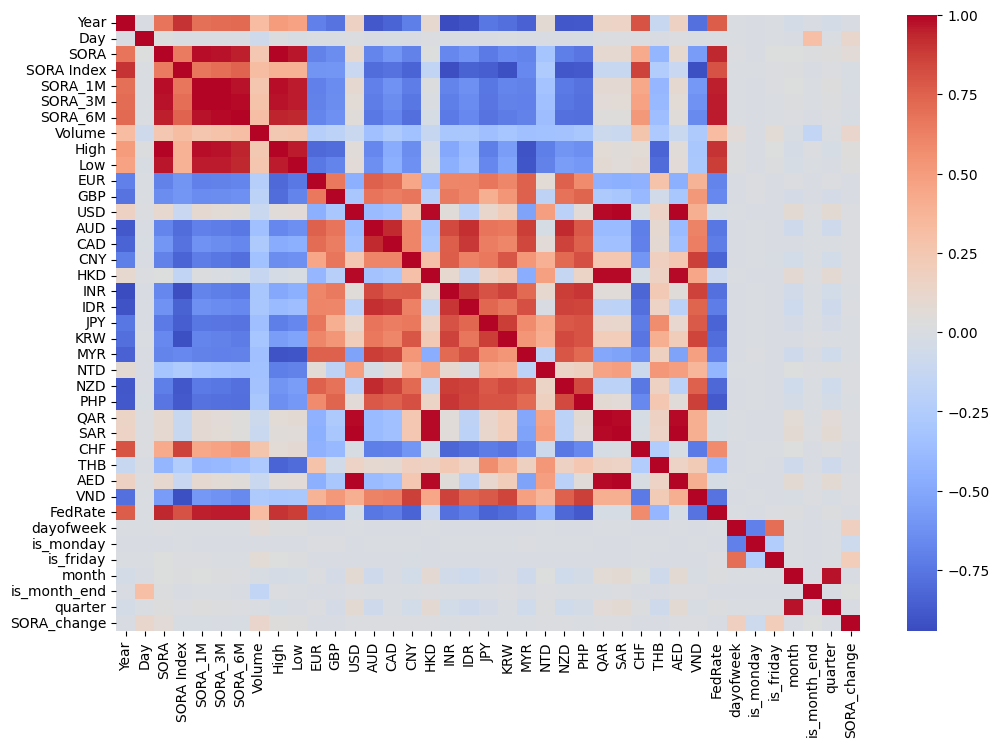

In [2299]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.show()

## Data Exploration 

In [2300]:
df["SORA"].describe()
df["SORA_change"] = df["SORA"].diff()
df["SORA_change"].describe()

count    3322.000000
mean        0.000294
std         0.151022
min        -1.262600
25%        -0.053700
50%         0.000500
75%         0.051900
max         1.482300
Name: SORA_change, dtype: float64

In [2301]:
df["SORA_change"].skew()

np.float64(0.16485383507612772)

SORA changes feature a low mean but huge difference between min and max while skew is positive - rare but large spikes, upward movements tend to be more extreme than downward ones

In [2302]:
df["SORA"].autocorr(lag=1)
df["SORA"].autocorr(lag=2)
df["SORA_change"].autocorr(lag=1)

np.float64(-0.06227259569587043)

Small, negative correlation - if SORA goes up today it's slightly more likely to go down the next day

<Axes: >

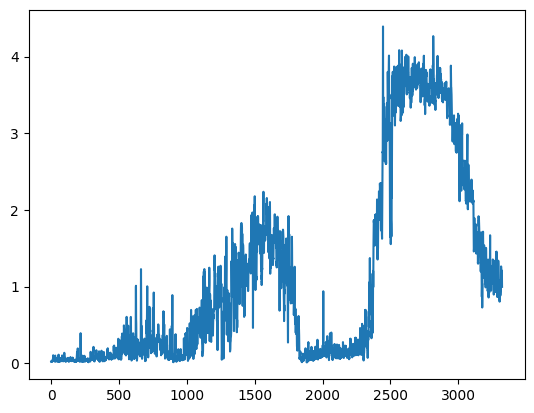

In [2303]:
df["SORA"].plot()

<Axes: >

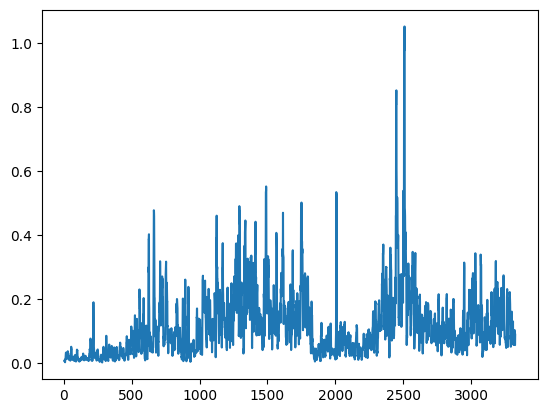

In [2304]:
df["volatility"] = df["SORA_change"].rolling(5).std()
df["volatility"].plot()

In [2305]:
df["range"] = df["High"] - df["Low"]
df["range"].describe()

C:\Users\FTW\AppData\Roaming\Python\Python312\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


count    1422.000000
mean        0.828610
std         0.537025
min         0.050000
25%         0.350000
50%         0.800000
75%         1.100000
max         2.750000
Name: range, dtype: float64

<Axes: >

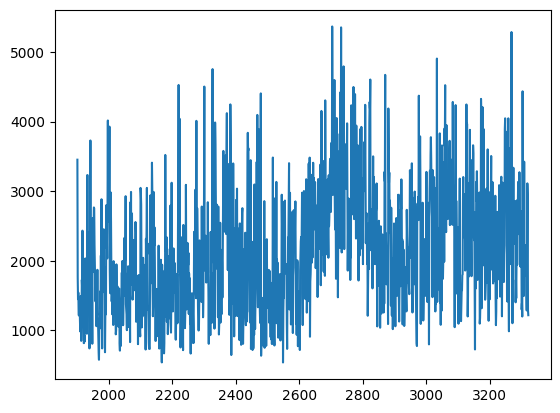

In [2306]:
df["Volume"].describe()
df["Volume"].plot()

In [2307]:
df[["SORA", "Volume"]].corr()

,SORA,Volume
SORA,1.000000,0.252802
Volume,0.252802,1.000000


0.25 correlation - weak to medium predictive power. 

In [2308]:
df[["SORA", "range"]].corr()

,SORA,range
SORA,1.000000,0.754799
range,0.754799,1.000000


Surprisingly high positive correlation - this indicates liquidity stress is a primary driver of the national rate movements. 

In [2309]:
df.groupby("dayofweek")["SORA_change"].mean()

dayofweek
0   -0.025220
1   -0.021300
2   -0.015110
3    0.001393
4    0.062447
Name: SORA_change, dtype: float64

Monday to wednesday negative, friday stands out positive even though its still a low predictive power. This could mean they're borrowing more for the weekends? Since banks are closed they borrow more to cover 3 days of exposure (sat, sun, mon). 

In [2310]:
import scipy.stats as stats

fri = df[df["dayofweek"] == 4]["SORA_change"]
others = df[df["dayofweek"] != 4]["SORA_change"]

stats.ttest_ind(fri, others, nan_policy="omit")

TtestResult(statistic=np.float64(12.005986863616853), pvalue=np.float64(1.5445422414664378e-32), df=np.float64(3320.0))

pvalue for "friday effect" is 2.6e-32. It's real even though the predictive power is low. 

In [2311]:
groups = [
    df[df["dayofweek"] == i]["SORA_change"].dropna()
    for i in range(5)
]

import scipy.stats as stats
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(39.309517243386175), pvalue=np.float64(3.325991008528934e-32))

pvalue 6.9e-32. ANOVA discerns at least one weekday is radically different for mean SORA change. 

In [2312]:
threshold = df["SORA_change"].std() * 2
spikes = df[df["SORA_change"].abs() > threshold]
spikes.tail(10)

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,FedRate,dayofweek,is_monday,is_friday,month,is_month_end,quarter,SORA_change,volatility,range
3029,2025,Jan,31,03 Feb 2025,2.6325,1.098051,2.7985,2.8993,3.1468,1273.0,...,4.33,4,0,1,1,1,1,-0.4958,0.343460,0.90
3068,2025,Mar,27,28 Mar 2025,2.3592,1.101939,2.4144,2.5618,2.8404,2599.0,...,4.33,3,0,0,3,0,1,-0.6237,0.339341,0.55
3148,2025,Jul,23,24 Jul 2025,1.8136,1.108906,1.5619,1.8675,2.1581,3659.0,...,4.33,2,0,0,7,0,3,0.3572,0.221920,0.95
3176,2025,Sep,1,02 Sep 2025,0.7261,1.110662,1.3354,1.5488,1.9134,2118.0,...,4.33,0,1,0,9,0,3,-0.3135,0.174317,0.80
3178,2025,Sep,3,04 Sep 2025,1.4808,1.110736,1.3111,1.5320,1.9002,4206.0,...,4.33,2,0,0,9,0,3,0.5493,0.309233,1.10
3190,2025,Sep,19,22 Sep 2025,1.5372,1.111532,1.2957,1.4879,1.8166,3035.0,...,4.08,4,0,1,9,0,3,0.4243,0.244298,1.40
3220,2025,Nov,3,04 Nov 2025,1.0306,1.113176,1.2448,1.3143,1.5717,1076.0,...,3.87,0,1,0,11,0,4,-0.3209,0.235070,0.70
3235,2025,Nov,24,25 Nov 2025,1.2670,1.113906,1.1527,1.2434,1.4491,1574.0,...,3.88,0,1,0,11,0,4,-0.4015,0.266032,0.80
3261,2025,Dec,31,02 Jan 2026,0.8949,1.115252,1.1739,1.1857,1.3195,988.0,...,3.64,2,0,0,12,1,4,-0.4263,0.205646,0.70
3282,2026,Jan,30,02 Feb 2026,1.1092,1.116330,1.1382,1.1502,1.2384,1404.0,...,3.64,4,0,1,1,0,1,-0.3461,0.221989,0.70


190 spikes across 3312 observations - 5.7%. SORA has somewhat frequent extreme movements relative to normal distribution.

In [2313]:
spikes["dayofweek"].value_counts(normalize=True)

dayofweek
4    0.267016
3    0.235602
0    0.183246
1    0.172775
2    0.141361
Name: proportion, dtype: float64

In [2314]:
df["dayofweek"].value_counts(normalize=True)

dayofweek
3    0.203130
1    0.202528
2    0.200722
4    0.197111
0    0.196509
Name: proportion, dtype: float64

In [2315]:
from scipy.stats import chisquare

observed = spikes["dayofweek"].value_counts().sort_index()
expected = df["dayofweek"].value_counts().sort_index() * (len(spikes) / len(df))

chisquare(observed, expected)

Power_divergenceResult(statistic=np.float64(10.085530561845015), pvalue=np.float64(0.039011315036931345))

chisq = 10.29 and pvalue = 0.03, statistically significant. Spike occurence depends on day of week. 

In [2316]:
positive_spikes = spikes[spikes["SORA_change"] > 0]
negative_spikes = spikes[spikes["SORA_change"] < 0]
positive_spikes["dayofweek"].value_counts(normalize=True)


dayofweek
4    0.467391
3    0.239130
0    0.108696
1    0.108696
2    0.076087
Name: proportion, dtype: float64

In [2317]:
negative_spikes["dayofweek"].value_counts(normalize=True)

dayofweek
0    0.252525
1    0.232323
3    0.232323
2    0.202020
4    0.080808
Name: proportion, dtype: float64

In [2318]:
pos = df[df["SORA_change"] > 0]["SORA_change"]
neg = df[df["SORA_change"] < 0]["SORA_change"]

pos.mean(), neg.mean(), pos.std(), neg.std()

(np.float64(0.09347329749103943),
 np.float64(-0.09470024360535931),
 np.float64(0.11955044746791019),
 np.float64(0.11704592961911897))

In [2319]:
large_moves = df[df["SORA_change"].abs() > df["SORA_change"].std()]

large_moves["SORA_change"].shift(-1).corr(large_moves["SORA_change"])

np.float64(-0.19741763080558405)

In [2320]:
df["volatility"] = df["SORA_change"].rolling(5).std()

df[["SORA", "volatility"]].corr()

,SORA,volatility
SORA,1.000000,0.319451
volatility,0.319451,1.000000


In [2321]:
df.groupby("dayofweek")["SORA_change"].std()

dayofweek
0    0.147672
1    0.136377
2    0.128931
3    0.161127
4    0.161448
Name: SORA_change, dtype: float64

In [2322]:
spikes["SORA_change"].describe()

count    191.000000
mean      -0.004679
std        0.479314
min       -1.262600
25%       -0.401400
50%       -0.305000
75%        0.404450
max        1.482300
Name: SORA_change, dtype: float64

In [2323]:
df[["SORA_change", "range"]].corr()

,SORA_change,range
SORA_change,1.000000,0.032847
range,0.032847,1.000000


In [2324]:
spikes = df[df["SORA_change"].abs() > threshold]
normal = df[df["SORA_change"].abs() <= threshold]

spikes[["Volume", "range"]].mean()
normal[["Volume", "range"]].mean()

Volume    2150.762509
range        0.797904
dtype: float64

In [2325]:
from statsmodels.tsa.stattools import adfuller

adfuller(df["SORA_change"].dropna())

(np.float64(-16.095909207797988),
 np.float64(5.193334672004632e-29),
 27,
 3294,
 {'1%': np.float64(-3.4323367648004606),
  '5%': np.float64(-2.8624178351722858),
  '10%': np.float64(-2.5672372898489977)},
 np.float64(-3348.731633186403))

Adfuller test pvalue of 5.3^e-29. SORA changes are strongly stationary.

## Feature eng

Liquidity (intraday range)

In [2326]:
df["range_norm"] = df["range"] / df["SORA"]
df["range_z"] = (df["range"] - df["range"].mean()) / df["range"].std()

In [2327]:
df[["range_z", "SORA", "SORA_change"]].corr()

,range_z,SORA,SORA_change
range_z,1.000000,0.754799,0.032847
SORA,0.754799,1.000000,0.059691
SORA_change,0.032847,0.059691,1.000000


Confirms earlier testing that intraday range measures stress level not direction of movement. Can be used later for model.

Volatlity 

In [2328]:
df["vol_5"] = df["SORA_change"].rolling(5).std()
df["vol_10"] = df["SORA_change"].rolling(10).std()

In [2329]:
df[["vol_5", "SORA"]].corr()


,vol_5,SORA
vol_5,1.000000,0.319451
SORA,0.319451,1.000000


In [2330]:
df[["vol_5", "SORA_change"]].corr()

,vol_5,SORA_change
vol_5,1.000000,-0.041328
SORA_change,-0.041328,1.000000


Volatility correlated with sora level like intraday range not movement

Mean Reversion

In [2331]:
df["lag1"] = df["SORA_change"].shift(1)
df["lag2"] = df["SORA_change"].shift(2)
df["lag3"] = df["SORA_change"].shift(3)

In [2332]:
df[["lag1", "SORA_change"]].corr()

,lag1,SORA_change
lag1,1.000000,-0.062273
SORA_change,-0.062273,1.000000


In [2333]:
df["large_move"] = (df["SORA_change"].abs() > df["SORA_change"].std()).astype(int)

In [2334]:
df[df["large_move"] == 1][["lag1", "SORA_change"]].corr()

,lag1,SORA_change
lag1,1.000000,-0.090905
SORA_change,-0.090905,1.000000


Mean reversion exists and is about 1.5x stronger when movement is large

Add direction to see if we can guess up or down and turn it into a classification problem instead

In [2335]:
df["direction"] = (df["SORA_change"] > 0).astype(int)

Weekday effects

In [2336]:
df.groupby("is_friday")["SORA_change"].mean()

is_friday
0   -0.014971
1    0.062447
Name: SORA_change, dtype: float64

In [2337]:
df.groupby("is_monday")["SORA_change"].mean()

is_monday
0    0.006536
1   -0.025220
Name: SORA_change, dtype: float64

Spikes 

In [2338]:
threshold = df["SORA_change"].std() * 2
df["is_spike"] = (df["SORA_change"].abs() > threshold).astype(int)

In [2339]:
df.groupby("is_spike")["vol_5"].mean()

is_spike
0    0.107142
1    0.307382
Name: vol_5, dtype: float64

Volatility is 3x higher during a spike

Regime 

In [2340]:
df["high_sora"] = (df["SORA"] > df["SORA"].median()).astype(int)

In [2341]:
df.groupby("high_sora")["vol_5"].mean()

high_sora
0    0.06950
1    0.16772
Name: vol_5, dtype: float64

High-rate environments are ~2.4x more volatile (0.16 vs 0.06)

fx

In [2342]:
fx_cols = [
    "EUR","GBP","USD","AUD","CAD","CNY","HKD","INR","IDR","JPY",
    "KRW","MYR","NTD","NZD","PHP","QAR","SAR","CHF","THB","AED","VND"
]

for col in fx_cols:
    # returns
    df[f"{col}_ret"] = df[col].pct_change()
    
    # lagged returns
    df[f"{col}_ret_lag1"] = df[f"{col}_ret"].shift(1)
    df[f"{col}_ret_lag2"] = df[f"{col}_ret"].shift(2)
    
    # volatility
    df[f"{col}_vol_5"] = df[f"{col}_ret"].shift(1).rolling(5).std()

df.tail()

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2119229663.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_ret"] = df[col].pct_change()
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2119229663.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_ret_lag1"] = df[f"{col}_ret"].shift(1)
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2119229663.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,THB_ret_lag2,THB_vol_5,AED_ret,AED_ret_lag1,AED_ret_lag2,AED_vol_5,VND_ret,VND_ret_lag1,VND_ret_lag2,VND_vol_5
3318,2026,Mar,25,26 Mar 2026,1.1783,1.117958,1.0054,1.0743,1.1364,2372.0,...,-0.006620,0.006888,0.000000,-0.003149,0.002583,0.003391,0.000000,-0.004104,0.001850,0.003406
3319,2026,Mar,26,27 Mar 2026,1.1312,1.117992,1.0101,1.0733,1.1350,3112.0,...,0.008286,0.006779,0.002585,0.000000,-0.003149,0.003256,0.002885,0.000000,-0.004104,0.003188
3320,2026,Mar,27,30 Mar 2026,1.2085,1.118103,1.0286,1.0715,1.1322,2933.0,...,-0.003752,0.005816,0.002578,0.002585,0.000000,0.002669,0.002466,0.002885,0.000000,0.002815
3321,2026,Mar,30,31 Mar 2026,1.1552,1.118139,1.0327,1.0697,1.1324,1293.0,...,0.002972,0.005814,0.001714,0.002578,0.002585,0.002534,0.002050,0.002466,0.002885,0.002861
3322,2026,Mar,31,01 Apr 2026,0.9954,1.118169,1.0308,1.0708,1.1313,1219.0,...,0.000128,0.004392,0.002852,0.001714,0.002578,0.002419,0.002659,0.002050,0.002466,0.002884


USD fx foes not seem to have much predictive power over daily sora change

reversion strength, volatility & weekday features

In [2343]:
df["reversion_signal"] = -df["lag1"] * df["large_move"]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2567893739.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["reversion_signal"] = -df["lag1"] * df["large_move"]


In [2344]:
df["high_vol"] = (df["vol_5"] > df["vol_5"].median()).astype(int)

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1894133959.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["high_vol"] = (df["vol_5"] > df["vol_5"].median()).astype(int)


In [2345]:
df["lag1_high_vol"] = df["lag1"] * df["high_vol"]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1616993674.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag1_high_vol"] = df["lag1"] * df["high_vol"]


In [2346]:
df["week_position"] = df["dayofweek"] / 4 

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1127735145.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["week_position"] = df["dayofweek"] / 4


Shock Persistence

In [2347]:
df["prev_spike"] = df["is_spike"].shift(1)

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\878802312.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["prev_spike"] = df["is_spike"].shift(1)


Rolling mean

In [2348]:
df["sora_ma5"] = df["SORA"].rolling(5).mean()

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2233550031.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sora_ma5"] = df["SORA"].rolling(5).mean()


More relevant currencies

In [2349]:
for c in ["USD", "CNY", "JPY", "EUR", "MYR"]:
    df[f"{c}_ret"] = df[c].pct_change()

In [2350]:
df["lag1_sq"] = df["lag1"] ** 2
df["lag1_abs"] = df["lag1"].abs()

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2772460467.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag1_sq"] = df["lag1"] ** 2
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2772460467.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag1_abs"] = df["lag1"].abs()


In [2351]:
df["lag1_friday"] = df["lag1"] * df["is_friday"]
df["lag1_monday"] = df["lag1"] * df["is_monday"]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\3301565238.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag1_friday"] = df["lag1"] * df["is_friday"]
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\3301565238.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag1_monday"] = df["lag1"] * df["is_monday"]


In [2352]:
df["pre_weekend"] = df["dayofweek"].isin([3,4]).astype(int)

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1362114204.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pre_weekend"] = df["dayofweek"].isin([3,4]).astype(int)


In [2353]:
streak_raw = (df["SORA_change"] > 0).astype(int)

df["streak"] = (
    streak_raw.shift(1)
    .groupby((streak_raw.shift(1) != streak_raw.shift(1).shift()).cumsum())
    .cumcount()
)

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\3363413145.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["streak"] = (


In [2354]:
df["sora_ma5"] = df["SORA"].shift(1).rolling(5).mean()
df["distance_from_mean"] = df["SORA"].shift(1) - df["sora_ma5"]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2202939850.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["distance_from_mean"] = df["SORA"].shift(1) - df["sora_ma5"]


In [2355]:
df["vol_spike"] = (df["vol_5"] > df["vol_5"].quantile(0.9)).astype(int)

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1201768140.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["vol_spike"] = (df["vol_5"] > df["vol_5"].quantile(0.9)).astype(int)


In [2356]:
df["MYR_ret_lag1"] = df["MYR_ret"].shift(1)
df["USD_ret_lag1"] = df["USD_ret"].shift(1)
df["CNY_ret_lag1"] = df["CNY_ret"].shift(1)

In [2357]:
df["MYR_vol"] = df["MYR_ret"].rolling(5).std()
df["USD_vol"] = df["MYR_ret"].rolling(5).std()
df["CNY_vol"] = df["CNY_ret"].rolling(5).std()

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2025295342.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["MYR_vol"] = df["MYR_ret"].rolling(5).std()
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2025295342.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["USD_vol"] = df["MYR_ret"].rolling(5).std()
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2025295342.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

Experimental Models + Prediction

In [2358]:
df_model = df[
    [
        "SORA_change",
        "lag1",
        "is_friday",
        "is_monday",
        "vol_5",
        "range_z",
        "reversion_signal"
    ]
].dropna()

In [2359]:
y = df_model["SORA_change"]
X = df_model.drop(columns=["SORA_change"])

In [2360]:
split = int(len(df_model) * 0.8)

In [2361]:
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [2362]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [2363]:
preds = model.predict(X_test)

import numpy as np

print(np.corrcoef(preds, y_test)[0,1])

0.049588791141536956


In [2364]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(rmse)

0.14697379661763849


In [2365]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

alphas = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 134, 200]}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    Ridge(),
    alphas,
    cv=tscv,
    scoring="neg_mean_squared_error"
)

grid.fit(X, y)

print(grid.best_params_)

{'alpha': 134}


In [2366]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=134)
ridge.fit(X_train, y_train)

,alpha,134
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [2367]:
ridge_preds = ridge.predict(X_test)

import numpy as np

print(np.corrcoef(ridge_preds, y_test)[0,1])

0.10750650079245075


In [2368]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
print(ridge_rmse)

0.13789653176365319


In [2369]:
features = [
    "lag1",
    "lag2",
    "lag3",
    "is_friday",
    "is_monday",
    "vol_5",
    "range_z",
    "reversion_signal",
    "lag1_high_vol",
    "distance_from_mean"
]

In [2370]:
log_features = [
    "lag1",
    "lag2",
    "lag3",
    "is_friday",
    "is_monday",
    "vol_5",
    "range_z",
    "reversion_signal",
    "lag1_high_vol",
    "distance_from_mean",
    "NZD_ret_lag1",
    "CNY_ret_lag1",
    "PHP_ret_lag1",
    "EUR_ret_lag2",
    "CAD_ret_lag1",
    "CAD_vol_5",
    "HKD_ret_lag1",
    "KRW_ret_lag1"
    ]

log_df = df[log_features + ["direction"]].dropna()
                                                                                                                                                  
X = log_df[log_features]
y = log_df["direction"]

In [2371]:
log_split = int(len(log_df) * 0.8)

X_log_train, X_log_test = X[:log_split], X[log_split:]
y_log_train, y_log_test = y[:log_split], y[log_split:]

In [2372]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {"C": [0.01, 0.1, 1, 10, 100, 500, 1000],
          "penalty": ["l2"]}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    params,
    cv=tscv,
    scoring="roc_auc"
)

grid.fit(X_log_train, y_log_train)

print(grid.best_params_)

{'C': 0.1, 'penalty': 'l2'}


In [2373]:
model = LogisticRegression(
    penalty="l2",
    C=0.1,        # inverse of regularization strength
    max_iter=2000
)
model.fit(X_log_train, y_log_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [2374]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

log_preds = model.predict(X_log_test)
accuracy_score(y_log_test, log_preds)

0.5578947368421052

In [2375]:
log_probs = model.predict_proba(X_log_test)[:, 1]

In [2376]:
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = np.arange(0.4, 0.7, 0.01)

best_acc = 0
best_thresh = 0.5

for t in thresholds:
    preds = (log_probs > t).astype(int)
    acc = accuracy_score(y_log_test, preds)
    
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best accuracy:", best_acc)

Best threshold: 0.6600000000000003
Best accuracy: 0.5824561403508772


In [2377]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_log_test, log_probs)

0.5812839506172839

In [2378]:
import pandas as pd
pd.Series(model.coef_[0], index=X.columns).sort_values()

distance_from_mean   -0.394343
is_monday            -0.339019
lag1                 -0.287998
lag1_high_vol        -0.267966
lag3                 -0.212751
lag2                 -0.146322
vol_5                -0.059112
NZD_ret_lag1         -0.004042
EUR_ret_lag2         -0.003771
CNY_ret_lag1         -0.003346
PHP_ret_lag1         -0.002273
HKD_ret_lag1         -0.001065
KRW_ret_lag1         -0.000258
CAD_vol_5             0.001772
CAD_ret_lag1          0.002353
range_z               0.008775
reversion_signal      0.167270
is_friday             1.093696
dtype: float64

In [2379]:
model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1000,
    max_iter=2000
)

model_l1.fit(X_log_train, y_log_train)

import pandas as pd
pd.Series(model_l1.coef_[0], index=X.columns)

lag1                  -0.892589
lag2                  -0.520189
lag3                  -0.551374
is_friday              1.430758
is_monday             -0.294935
vol_5                 -0.430039
range_z                0.034702
reversion_signal       0.392063
lag1_high_vol         -0.294292
distance_from_mean    -0.418283
NZD_ret_lag1         -21.479178
CNY_ret_lag1         -30.749441
PHP_ret_lag1         -11.052211
EUR_ret_lag2         -22.752099
CAD_ret_lag1          20.893344
CAD_vol_5             59.224966
HKD_ret_lag1          -3.621564
KRW_ret_lag1           4.044530
dtype: float64

In [2380]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# params = {
#     "max_depth": [4, 5],
#     "n_estimators": [10, 50, 100],
#     "learning_rate": [0.03, 0.04, 0.05],
#     "subsample": [0.7, 0.8, 0.9, 1.0]
# }

# grid = GridSearchCV(
#     XGBClassifier(eval_metric="auc"),
#     params,
#     cv=TimeSeriesSplit(n_splits=5),
#     scoring="roc_auc"
# )

# grid.fit(X, y)

# print(grid.best_params_)

In [2381]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# Base features
base_features = log_features.copy()
results = []

# Iterate through columns
for col in fx_cols:
    # List of features to test for this column
    candidate_features = [
        f"{col}_ret_lag1",
        f"{col}_ret_lag2",
        f"{col}_vol5"
    ]
    
    for feature in candidate_features:
        if feature not in df.columns:
            continue
        
        # Prepare features
        features = base_features + [feature]
        features = list(dict.fromkeys(features))  # remove duplicates just in case
        
        X = df[features].apply(pd.to_numeric, errors='coerce')
        y = df["direction"].copy()
        
        # Drop rows with NaNs
        X = X.dropna()
        y = y.loc[X.index]
        
        # Train/test split
        split = int(len(X) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]
        
        # Train model
        model = XGBClassifier(eval_metric="auc")
        model.fit(X_train, y_train)
        
        # Predict & calculate AUC
        probs = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probs)
        results.append((feature, auc))

# Sort results by AUC descending
results.sort(key=lambda x: x[1], reverse=True)

# Print pretty table
print(f"{'Feature':<25} {'AUC':>6}")
print("-" * 32)
for feature, auc in results:
    print(f"{feature:<25} {auc:>6.4f}")

Feature                      AUC
--------------------------------
VND_ret_lag2              0.6744
EUR_ret_lag2              0.6592
CAD_ret_lag1              0.6592
CNY_ret_lag1              0.6592
HKD_ret_lag1              0.6592
KRW_ret_lag1              0.6592
NZD_ret_lag1              0.6592
PHP_ret_lag1              0.6592
CHF_ret_lag2              0.6576
QAR_ret_lag1              0.6564
IDR_ret_lag2              0.6506
USD_ret_lag1              0.6500
AUD_ret_lag1              0.6499
USD_ret_lag2              0.6445
JPY_ret_lag1              0.6425
AED_ret_lag1              0.6414
AUD_ret_lag2              0.6409
NZD_ret_lag2              0.6401
HKD_ret_lag2              0.6372
SAR_ret_lag2              0.6369
CNY_ret_lag2              0.6357
KRW_ret_lag2              0.6352
THB_ret_lag1              0.6351
AED_ret_lag2              0.6348
EUR_ret_lag1              0.6335
NTD_ret_lag1              0.6334
MYR_ret_lag2              0.6322
INR_ret_lag1              0.6314
PHP_ret_la

In [2382]:
xgb = XGBClassifier(
    n_estimators=70,
    max_depth=5,
    learning_rate=0.04,
    subsample=1.0,
    colsample_bytree=1.0,
    eval_metric="auc"
)

xgb.fit(X_log_train, y_log_train)

probs_xgb = xgb.predict_proba(X_log_test)[:, 1]

In [2383]:
accuracy_score(y_log_test, probs_xgb > 0.5)

0.6070175438596491

In [2384]:
base_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print(base_auc)

0.6744197530864198


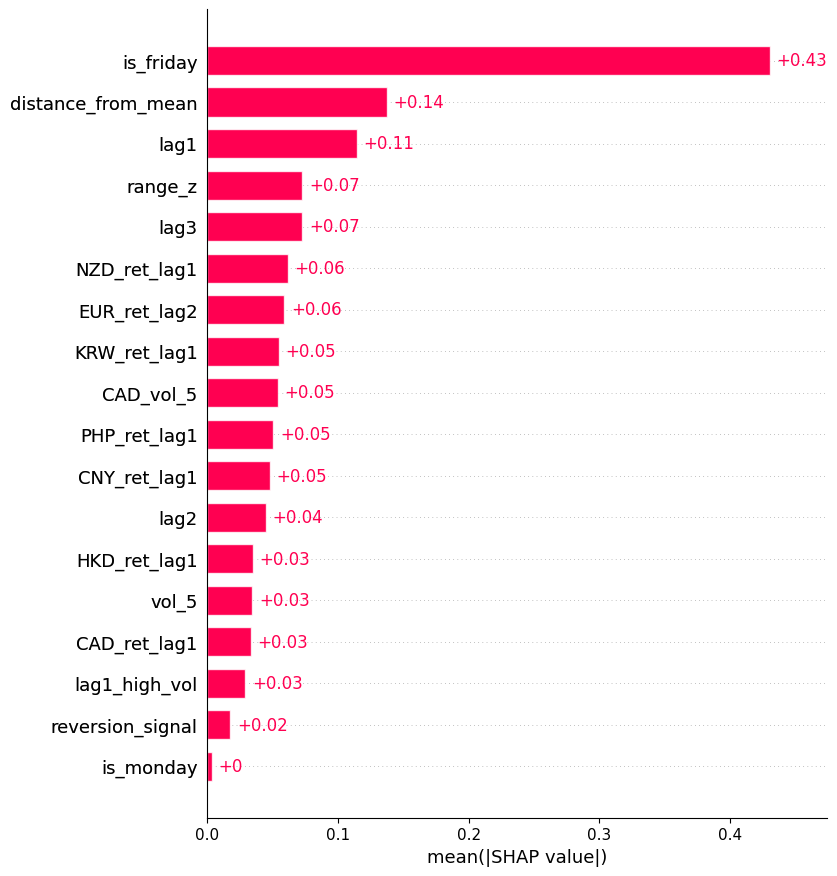

In [2423]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_log_test)

shap.plots.bar(shap_values, max_display=len(shap_values))

XGB (Greedy selection for features)

In [2386]:
selected = base_features.copy()
best_auc = base_auc   #current best 0.6744

In [2387]:
sorted_fx = sorted(results, key=lambda x: x[1], reverse=True)
print(sorted_fx)

[('VND_ret_lag2', 0.6744197530864198), ('EUR_ret_lag2', 0.6591604938271605), ('CAD_ret_lag1', 0.6591604938271605), ('CNY_ret_lag1', 0.6591604938271605), ('HKD_ret_lag1', 0.6591604938271605), ('KRW_ret_lag1', 0.6591604938271605), ('NZD_ret_lag1', 0.6591604938271605), ('PHP_ret_lag1', 0.6591604938271605), ('CHF_ret_lag2', 0.6575802469135803), ('QAR_ret_lag1', 0.6563950617283951), ('IDR_ret_lag2', 0.6506172839506174), ('USD_ret_lag1', 0.6500246913580248), ('AUD_ret_lag1', 0.6498765432098765), ('USD_ret_lag2', 0.6445432098765431), ('JPY_ret_lag1', 0.6424691358024691), ('AED_ret_lag1', 0.6413827160493828), ('AUD_ret_lag2', 0.6408888888888888), ('NZD_ret_lag2', 0.6401481481481481), ('HKD_ret_lag2', 0.6372345679012346), ('SAR_ret_lag2', 0.6368888888888888), ('CNY_ret_lag2', 0.6356543209876544), ('KRW_ret_lag2', 0.6351604938271606), ('THB_ret_lag1', 0.6350617283950617), ('AED_ret_lag2', 0.6347654320987653), ('EUR_ret_lag1', 0.6334814814814815), ('NTD_ret_lag1', 0.6334320987654322), ('MYR_ret_l

In [2388]:
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_auc_score
# from itertools import combinations
# from tqdm import tqdm

# candidate_suffixes = ["_ret_lag1", "_ret_lag2", "_vol_5"]

# # Build all candidate FX features
# all_candidate_features = [
#     f"{col}{suffix}" 
#     for col in fx_cols 
#     for suffix in candidate_suffixes
#     if f"{col}{suffix}" in df.columns and f"{col}{suffix}" not in log_features
# ]

# selected = log_features.copy()
# best_auc = 0

# # Base features AUC
# X_base = df[selected].apply(pd.to_numeric, errors="coerce").dropna()
# y_base = df.loc[X_base.index, "direction"]
# split = int(len(X_base) * 0.8)
# X_train, X_test = X_base.iloc[:split], X_base.iloc[split:]
# y_train, y_test = y_base.iloc[:split], y_base.iloc[split:]
# model = XGBClassifier(eval_metric='auc')
# model.fit(X_train, y_train)
# best_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
# print(f"Base features AUC: {best_auc:.4f}")

# # --- Greedy search 1-4 FX features ---
# comb_list = []
# for r in [1, 2, 3, 4]:  
#     comb_list.extend(combinations(all_candidate_features, r))

# print(f"Testing {len(comb_list)} combinations...")

# for i, combo in enumerate(tqdm(comb_list, desc="Feature combos")):
#     temp_features = list(dict.fromkeys(selected + list(combo)))  # remove duplicates

#     X = df[temp_features].apply(pd.to_numeric, errors="coerce").dropna()
#     y = df.loc[X.index, "direction"]

#     split = int(len(X) * 0.8)
#     X_train, X_test = X.iloc[:split], X.iloc[split:]
#     y_train, y_test = y.iloc[:split], y.iloc[split:]

#     model = XGBClassifier(eval_metric='auc')
#     model.fit(X_train, y_train)

#     auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

#     # Only print new best
#     if auc > best_auc:
#         best_auc = auc
#         selected = temp_features.copy()
#         tqdm.write(f"New best combo ({i}): {combo}, AUC: {auc:.4f}")

# print("Final selected features:", selected)
# print("Best AUC:", best_auc)

macro rolling validation

In [2389]:
# ===== FX FEATURE ENGINEERING =====

fx_cols = [
    "EUR","GBP","USD","AUD","CAD","CNY","HKD","INR","IDR","JPY",
    "KRW","MYR","NTD","NZD","PHP","QAR","SAR","CHF","THB","AED","VND"
]

# returns
for col in fx_cols:
    df[f"{col}_ret"] = df[col].pct_change()

# lagged returns
for col in fx_cols:
    df[f"{col}_ret_lag1"] = df[f"{col}_ret"].shift(1)
    df[f"{col}_ret_lag2"] = df[f"{col}_ret"].shift(2)

# volatility
for col in fx_cols:
    df[f"{col}_vol_5"] = df[f"{col}_ret"].shift(1).rolling(5).std()

# ===== STRUCTURED MACRO FEATURES =====

asia = ["CNY","MYR","THB","IDR","PHP","VND"]
g10  = ["USD","EUR","JPY","GBP","CHF","AUD","CAD"]

# regional volatility
df["asia_vol"] = df[[f"{c}_vol_5" for c in asia]].mean(axis=1)
df["g10_vol"]  = df[[f"{c}_vol_5" for c in g10]].mean(axis=1)

# global FX volatility
df["fx_vol_global"] = df[[f"{c}_vol_5" for c in fx_cols]].mean(axis=1)

# USD / oil proxy
df["usd_proxy"] = df["USD_ret_lag1"]
df["oil_proxy"] = df["AED_vol_5"]  # proxy for oil-linked flows

# interaction features
df["friday_high_vol"] = df["is_friday"] * df["vol_5"]
df["fx_stress"] = df["fx_vol_global"] * df["vol_5"]

df["asean_factor"] = df[[f"{c}_ret_lag1" for c in ["MYR","PHP","THB","IDR"]]].mean(axis=1)
df["europe_factor"] = df[[f"{c}_ret_lag1" for c in ["EUR","CHF"]]].mean(axis=1)
df["oil_factor"] = df[[f"{c}_vol_5" for c in ["AED","SAR"]]].mean(axis=1)
df["commonwealth_factor"] = df[[f"{c}_ret_lag1" for c in ["AUD","GBP"]]].mean(axis=1)

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\4124675943.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["asia_vol"] = df[[f"{c}_vol_5" for c in asia]].mean(axis=1)
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\4124675943.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["g10_vol"]  = df[[f"{c}_vol_5" for c in g10]].mean(axis=1)
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\4124675943.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

In [2390]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import numpy as np

# ===== SELECT FEATURES =====
features = [
    "lag1","lag2","lag3",
    "is_friday","is_monday",
    "vol_5","range_z",
    "reversion_signal",
    "lag1_high_vol",
    "distance_from_mean",
    
    # FX structured features
    "asean_factor",
    "europe_factor",
    "oil_factor",
    "commonwealth_factor",
    "fx_vol_global",
    "fx_stress"
]

# ===== CLEAN DATA =====
X = df[features].copy()
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna()

y = df.loc[X.index, "direction"]

# ===== ROLLING VALIDATION =====
tscv = TimeSeriesSplit(n_splits=5)

aucs = []

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(eval_metric="auc")
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    
    aucs.append(auc)
    print(f"Fold {i+1} AUC: {auc:.4f}")

print("\nMean AUC:", np.mean(aucs))
print("Std AUC :", np.std(aucs))

Fold 1 AUC: 0.6301
Fold 2 AUC: 0.6334
Fold 3 AUC: 0.6147
Fold 4 AUC: 0.6528
Fold 5 AUC: 0.6053

Mean AUC: 0.6272470848802552
Std AUC : 0.016363811083943153


SORA Coefficient (ΔSORA ≈ β × ΔFedRate)

In [2391]:
df["Fed_change"] = df["FedRate"].diff()

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2272826535.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Fed_change"] = df["FedRate"].diff()


In [2392]:
events = df[df["Fed_change"] != 0]

In [2393]:
pre = 7
post = 7

events["SORA_response"] = [
    df.loc[i-pre:i+post, "SORA_change"].sum()
    for i in events.index
]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2789519188.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events["SORA_response"] = [
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2789519188.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events["SORA_response"] = [


In [2394]:
from sklearn.linear_model import LinearRegression

X = events[["Fed_change"]]
y = events["SORA_response"]

LR = LinearRegression()
X.dropna(inplace=True)
y = y.loc[X.index]
LR.fit(X, y)

print("Beta:", LR.coef_[0])
print("R²:", LR.score(X, y))

Beta: 0.2782195431194285
R²: 0.012647077651077754


C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\740569472.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


Coeff validation w monthly smoothing

In [2395]:
df.tail()

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,fx_vol_global,usd_proxy,oil_proxy,friday_high_vol,fx_stress,asean_factor,europe_factor,oil_factor,commonwealth_factor,Fed_change
3318,2026,Mar,25,26 Mar 2026,1.1783,1.117958,1.0054,1.0743,1.1364,2372.0,...,0.003549,-0.002884,0.003391,0.000000,0.000366,0.000180,-0.000951,0.003515,-0.001013,0.0
3319,2026,Mar,26,27 Mar 2026,1.1312,1.117992,1.0101,1.0733,1.1350,3112.0,...,0.003459,-0.000235,0.003256,0.000000,0.000246,0.000029,0.000064,0.003304,0.000442,0.0
3320,2026,Mar,27,30 Mar 2026,1.2085,1.118103,1.0286,1.0715,1.1322,2933.0,...,0.003237,0.002502,0.002669,0.057448,0.000186,-0.000725,-0.000514,0.002695,-0.000699,0.0
3321,2026,Mar,30,31 Mar 2026,1.1552,1.118139,1.0327,1.0697,1.1324,1293.0,...,0.002849,0.002574,0.002534,0.000000,0.000160,-0.000364,-0.001047,0.002530,-0.001443,0.0
3322,2026,Mar,31,01 Apr 2026,0.9954,1.118169,1.0308,1.0708,1.1313,1219.0,...,0.002291,0.001712,0.002419,0.000000,0.000203,-0.000843,-0.001249,0.002405,-0.003437,0.0


In [2396]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

df["SORA"] = pd.to_numeric(df["SORA"], errors="coerce")
df["FedRate"] = pd.to_numeric(df["FedRate"], errors="coerce")

df_monthly = pd.DataFrame()
df_monthly["SORA"] = df["SORA"].resample("M").mean()
df_monthly["FedRate"] = df["FedRate"].resample("M").last()

df_monthly["SORA_change"] = df_monthly["SORA"].diff()
df_monthly["Fed_change"] = df_monthly["FedRate"].diff()

data = df_monthly[["Fed_change", "SORA_change"]].dropna()

X = data[["Fed_change"]]
y = data["SORA_change"]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\905221219.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly["SORA"] = df["SORA"].resample("M").mean()
C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\905221219.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly["FedRate"] = df["FedRate"].resample("M").last()


In [2397]:
LR.fit(X, y)
print("Beta:", LR.coef_[0])
print("R²:", LR.score(X, y))

Beta: 0.2994548931632842
R²: 0.09079571783061946


Coefficient Validation 3 - Distributed Lag

In [2398]:
df["Fed_lag1"] = df["Fed_change"].shift(1)
df["Fed_lag2"] = df["Fed_change"].shift(2)

In [2399]:
X = df[["Fed_change", "Fed_lag1", "Fed_lag2"]]
y = df["SORA_change"]

In [2400]:
X.dropna(inplace=True)
y = y.loc[X.index]

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1272493207.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


In [2401]:
LR.fit(X, y)
print("Beta:", LR.coef_[0])
print("R²:", LR.score(X, y))

Beta: 0.28608139083244727
R²: 0.008709186404786129


In [2420]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import numpy as np

features = [
    "lag1", "lag2", "lag3",
    "is_friday", "is_monday",
    "vol_5", "range_z",
    "reversion_signal", "lag1_high_vol",
    "distance_from_mean",
    "NZD_ret_lag1", "CNY_ret_lag1", "PHP_ret_lag1",
    "EUR_ret_lag2", "CAD_ret_lag1", "CAD_vol_5",
    "HKD_ret_lag1", "KRW_ret_lag1"
]

X = df[features].copy()
y = df["direction"]

data = X.copy()
data["y"] = y
data = data.dropna()

X = data[features]
y = data["y"]

tscv = TimeSeriesSplit(n_splits=5)

aucs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=70,
        max_depth=9,
        learning_rate=0.04,
        subsample=1.0,
        colsample_bytree=0.8,
        eval_metric="auc"
    )

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)

    aucs.append(auc)
    print(f"Fold {fold+1} AUC: {auc:.4f}")

print("\nMean AUC:", np.mean(aucs))
print("Std AUC :", np.std(aucs))

Fold 1 AUC: 0.6398
Fold 2 AUC: 0.6411
Fold 3 AUC: 0.6333
Fold 4 AUC: 0.6371
Fold 5 AUC: 0.6480

Mean AUC: 0.6398701516015909
Std AUC : 0.004872409061486287


In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")  # modern base

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

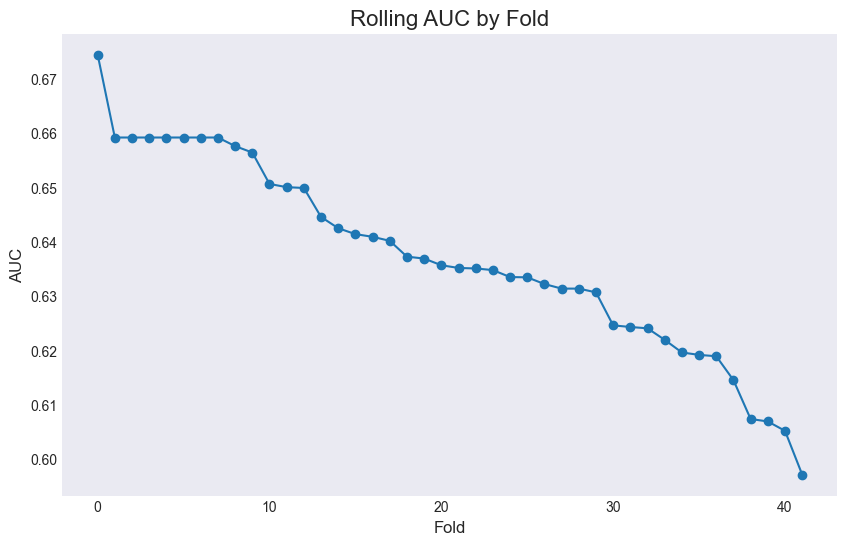

In [2432]:
plt.plot(aucs, marker='o')
plt.title("Rolling AUC by Fold")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.grid()
plt.show()

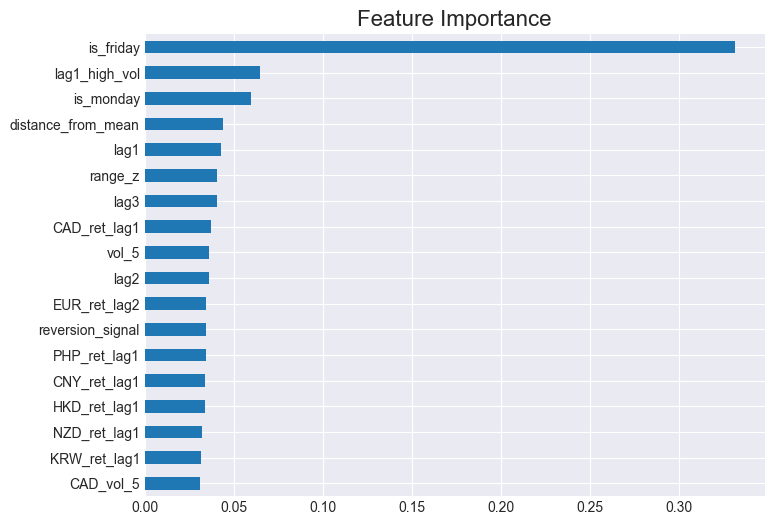

In [2433]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

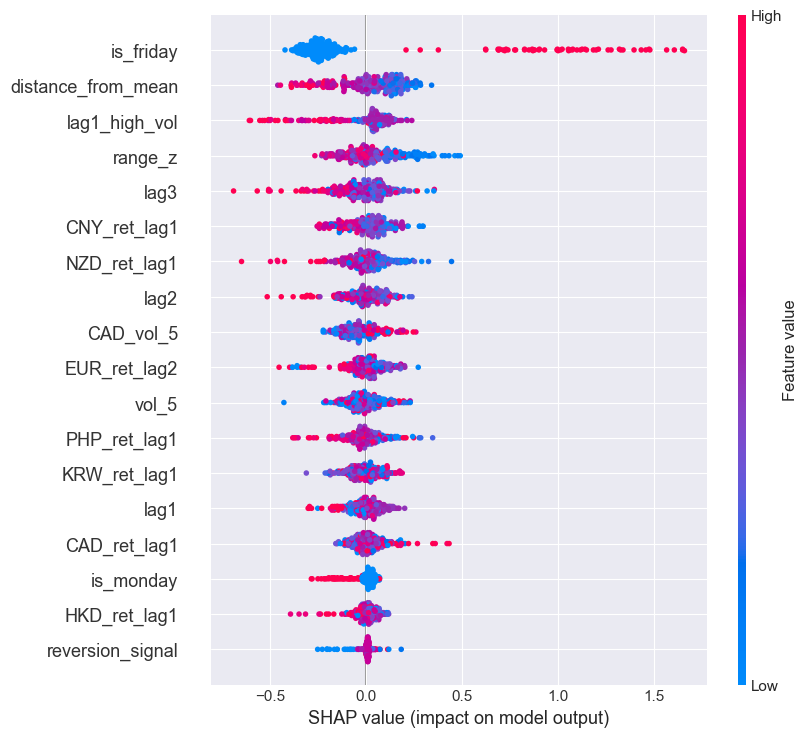

In [2434]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_log_test)

shap.plots.beeswarm(shap_values, max_display=len(shap_values))

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\2303380804.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




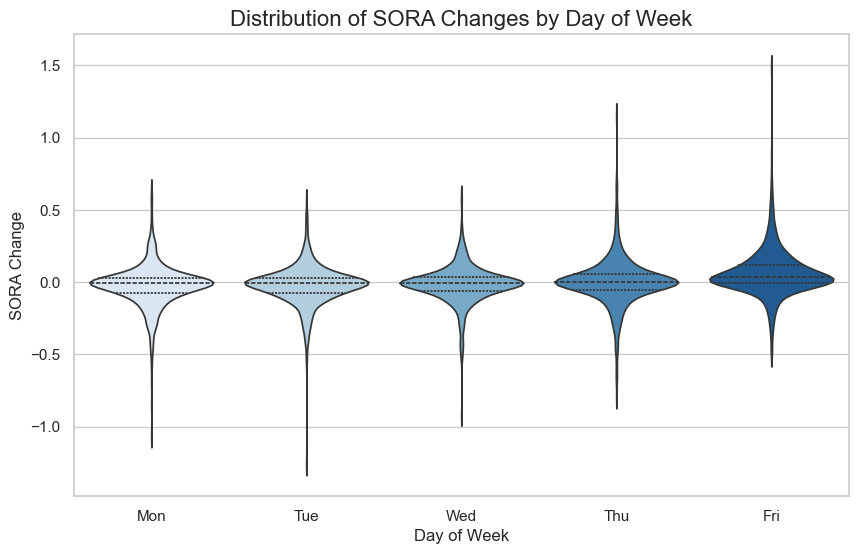

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri"]

df["day_name"] = df["dayofweek"].map({
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri"
})

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="day_name",
    y="SORA_change",
    order=day_order,
    palette="Blues",
    inner="quartile"  
)

plt.title("Distribution of SORA Changes by Day of Week", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("SORA Change")

plt.show()

In [ ]:
day_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri"
}

df_plot = df.copy()
df_plot["day_name"] = df_plot["dayofweek"].map(day_map)

# Aggregate first
df_grouped = df_plot.groupby("day_name")["SORA_change"].mean().reset_index()

fig = px.bar(
    df_grouped,
    x="day_name",
    y="SORA_change",
    title="Average SORA Change by Day of Week",
    color="SORA_change",
    color_continuous_scale="Blues",
    category_orders={"day_name": ["Mon", "Tue", "Wed", "Thu", "Fri"]}
)

fig.update_layout(template="plotly_white")

fig.show()

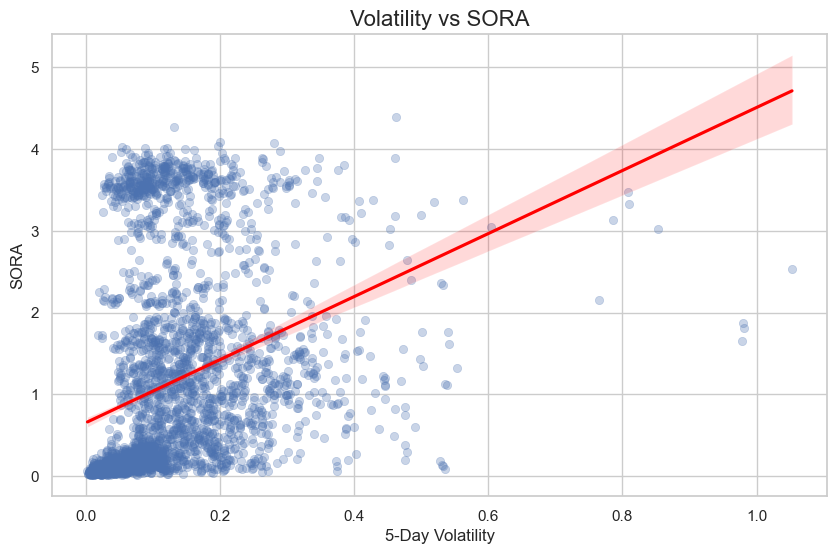

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="vol_5",
    y="SORA",
    alpha=0.3,
    edgecolor=None
)

sns.regplot(
    data=df,
    x="vol_5",
    y="SORA",
    scatter=False,
    color="red"
)

plt.title("Volatility vs SORA", fontsize=16)
plt.xlabel("5-Day Volatility")
plt.ylabel("SORA")

plt.show()

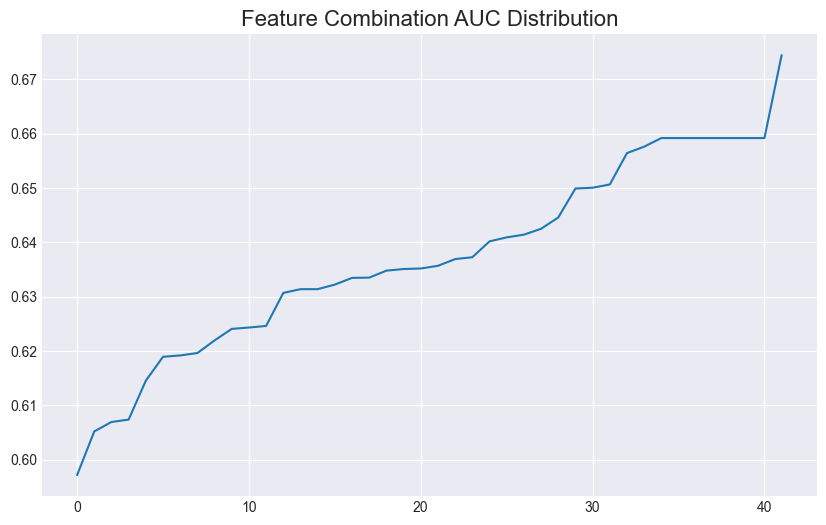

In [ ]:
aucs = [x[1] for x in results]

plt.plot(sorted(aucs))
plt.title("Feature Combination AUC Distribution")
plt.show()

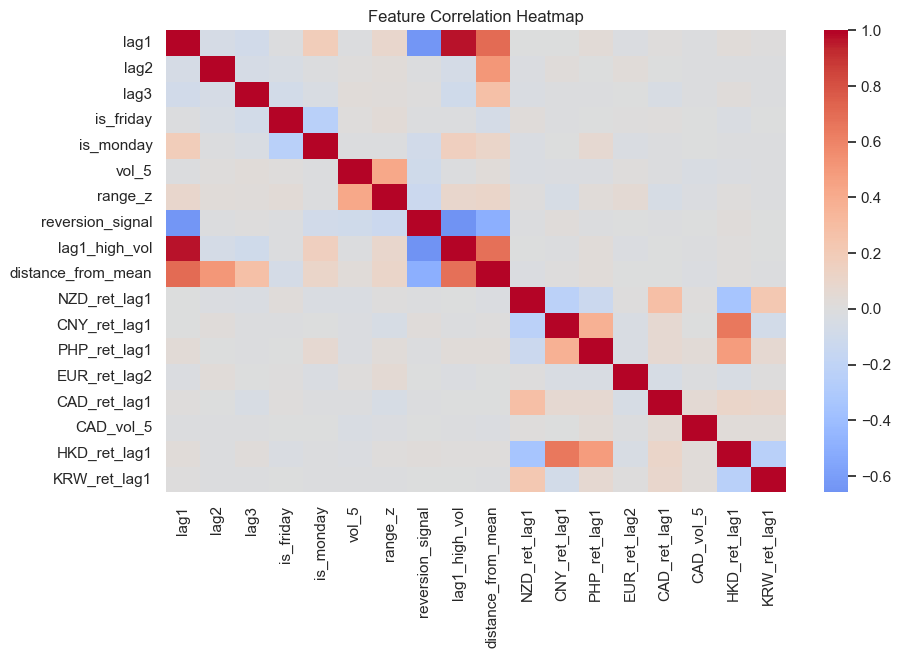

In [2445]:
corr = df[features].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [2458]:
spikes = df[df["is_spike"] == 1]

spikes["direction"] = (spikes["SORA_change"] > 0).map({True: "Positive", False: "Negative"})

fig = px.histogram(
    spikes,
    x="dayofweek",
    color="direction",
    barmode="group",
    title="Spike Direction by Day of Week"
)

fig.update_layout(xaxis=dict(
    tickmode='array',
    tickvals=[0,1,2,3,4],
    ticktext=['Mon','Tue','Wed','Thu','Fri']
))

fig.show()

C:\Users\FTW\AppData\Local\Temp\ipykernel_19168\1947514650.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

